In [13]:
import sys

assert sys.version_info >= (3, 7)

Scikit-Learn ≥1.0.1 is required:

In [14]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

Let's define the default font sizes, to plot pretty figures:

In [15]:
import matplotlib.pyplot as plt

plt.rc('font', size=12)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=12)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Make this notebook's output stable across runs:

In [16]:
import numpy as np

np.random.seed(42)

# Training-only

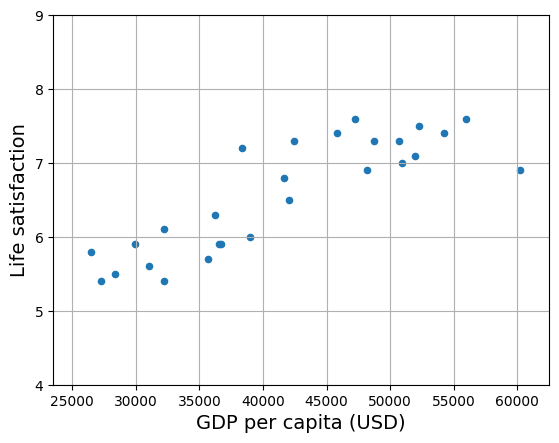

[[6.30165767]]


In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

# Download and prepare the data
data_root = "https://github.com/ageron/data/raw/main/"
lifesat = pd.read_csv(data_root + "lifesat/lifesat.csv")
X = lifesat[["GDP per capita (USD)"]].values
y = lifesat[["Life satisfaction"]].values

# Visualize the data
lifesat.plot(kind='scatter', grid=True, x="GDP per capita (USD)", y="Life satisfaction")
plt.axis([23_500, 62_500, 4, 9])
plt.show()

# Select a linear model
model = LinearRegression()

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
X_new = [[37_655.2]]  # Cyprus' GDP per capita in 2020
print(model.predict(X_new)) # outputs [[6.30165767]]

To add L2 regularization to the Linear Regression model:

In [18]:
from sklearn.linear_model import Ridge

# Initialize a Ridge regressor model with alpha=1.0
model_ridge = Ridge(alpha=1.0)

# Train the Ridge model
model_ridge.fit(X, y.ravel())

print("Ridge Regressor model trained successfully.")

Ridge Regressor model trained successfully.


Replacing the Linear Regression model with k-Nearest Neighbors (in this example, k = 3) regression in the previous code is as simple as replacing these two
lines:

```python
from sklearn.linear_model import LinearRegression

model = LinearRegression()
```

with these two:

```python
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)
```

In [19]:
# Select a 3-Nearest Neighbors regression model
from sklearn.neighbors import KNeighborsRegressor

model = KNeighborsRegressor(n_neighbors=3)

# Train the model
model.fit(X, y)

# Make a prediction for Cyprus
print(model.predict(X_new)) # outputs [[6.33333333]]


[[6.33333333]]


# Training and Testing
Build and evaluate a Random Forest Regressor model to predict life satisfaction based on GDP per capita, including data splitting, model training, cross-validation, performance evaluation on a test set, and visualization of predictions.

## Split Data

**Reasoning**:
Split the data into training and testing sets. Import the helper function `train_test_split` function and use it to split `X` and `y`.



In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Shape of X_train:", X_train.shape)
print("Shape of X_test:", X_test.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

Shape of X_train: (21, 1)
Shape of X_test: (6, 1)
Shape of y_train: (21, 1)
Shape of y_test: (6, 1)


## Train and Validate Random Forest Model


Importing necessary libraries, initialize a RandomForestRegressor, train it, perform cross-validation, and then calculate and print the mean and standard deviation of the cross-validation scores.



In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
import numpy as np

# Initialize a RandomForestRegressor model
model_rf = RandomForestRegressor(n_estimators=100, random_state=42)

# Train the model
model_rf.fit(X_train, y_train.ravel())
print("RandomForestRegressor model trained successfully.")

# Perform 5-fold cross-validation
cv_scores = cross_val_score(model_rf, X_train, y_train.ravel(),
                            scoring='neg_mean_squared_error', cv=5)

# Calculate mean and standard deviation of cross-validation scores
rmse_scores = np.sqrt(-cv_scores)

print(f"\nCross-validation RMSE scores: {rmse_scores}")
print(f"Mean RMSE: {rmse_scores.mean():.2f}")
print(f"Standard deviation of RMSE: {rmse_scores.std():.2f}")

RandomForestRegressor model trained successfully.

Cross-validation RMSE scores: [0.33856196 0.5311897  0.28598077 0.40390624 0.41458865]
Mean RMSE: 0.39
Standard deviation of RMSE: 0.08


## Evaluate Model on Test Set


To evaluate the model's performance, import the necessary metrics from `sklearn.metrics`, make predictions on the test set, and then calculate and print the MSE, RMSE, and R-squared scores.



In [22]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

# Make predictions on the test set
y_pred_rf = model_rf.predict(X_test)

# Calculate Mean Squared Error (MSE)
mse_rf = mean_squared_error(y_test, y_pred_rf)

# Calculate Root Mean Squared Error (RMSE)
rmse_rf = np.sqrt(mse_rf)

# Calculate R-squared score
r2_rf = r2_score(y_test, y_pred_rf)

# Print the evaluation metrics
print(f"Random Forest Model Performance on Test Set:")
print(f"  Mean Squared Error (MSE): {mse_rf:.4f}")
print(f"  Root Mean Squared Error (RMSE): {rmse_rf:.4f}")
print(f"  R-squared (R2) Score: {r2_rf:.4f}")

Random Forest Model Performance on Test Set:
  Mean Squared Error (MSE): 0.3091
  Root Mean Squared Error (RMSE): 0.5559
  R-squared (R2) Score: -0.0782


## Visualize Predictions


Visualize the actual versus predicted life satisfaction values. Create a scatter plot using matplotlib, plotting `y_test` against `y_pred_rf`, adding labels, a title, a diagonal line for perfect predictions, and a legend.



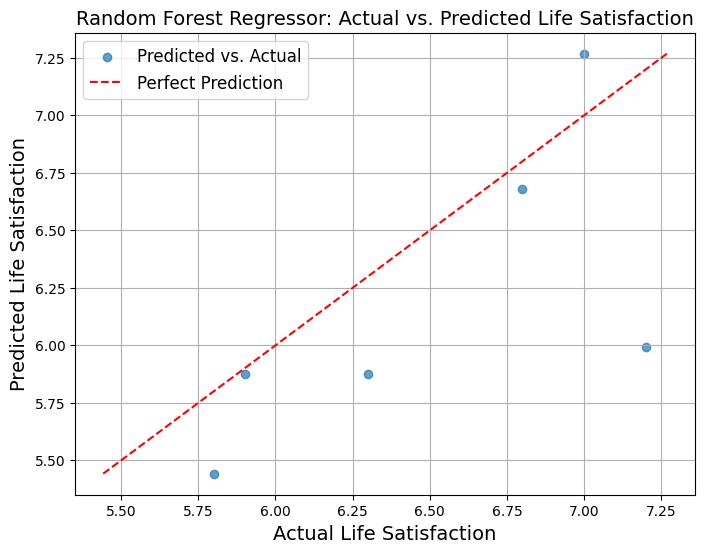

In [23]:
import matplotlib.pyplot as plt

# Create a scatter plot
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred_rf, alpha=0.7, label='Predicted vs. Actual')

# Add a diagonal line for perfect predictions
min_val = min(y_test.min(), y_pred_rf.min())
max_val = max(y_test.max(), y_pred_rf.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Perfect Prediction')

# Add labels and title
plt.xlabel("Actual Life Satisfaction")
plt.ylabel("Predicted Life Satisfaction")
plt.title("Random Forest Regressor: Actual vs. Predicted Life Satisfaction")
plt.grid(True)
plt.legend()
plt.show()

## Summary:

The end-to-end Random Forest regression process involved splitting the data, training a Random Forest Regressor model, validating it using cross-validation, evaluating its performance on a held-out test set, and visualizing the predictions.

### Data Analysis Key Findings
*   **Data Splitting**: The dataset was successfully split into training (21 samples for X\_train and y\_train) and testing (6 samples for X\_test and y\_test) sets, with approximately 80% for training and 20% for testing.
*   **Model Training and Cross-Validation**: A Random Forest Regressor model with 100 estimators was trained.
    *   Five-fold cross-validation on the training data yielded a mean Root Mean Squared Error (RMSE) of 0.39.
    *   The standard deviation of the RMSE was 0.08, indicating relatively consistent performance across different training data subsets.
*   **Test Set Evaluation**:
    *   The Mean Squared Error (MSE) on the test set was 0.3091.
    *   The Root Mean Squared Error (RMSE) on the test set was 0.5559.
    *   The R-squared (R2) score on the test set was -0.0782, suggesting that the model performs worse than simply predicting the mean of the target variable for the test set.
*   **Prediction Visualization**: A scatter plot was generated to compare actual versus predicted life satisfaction values on the test set, including a reference line for perfect predictions.

### Insights or Next Steps
*   The negative R-squared score on the test set indicates that the current Random Forest model does not capture the underlying relationship in the data effectively, and its predictions are not better than a baseline model predicting the mean.
*   Further investigation is needed to improve model performance, potentially by exploring other regression models, performing feature engineering, or gathering more data, especially given the small test set size (6 samples).
